In [1]:
!pip install chembl_webresource_client rdkit lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.5 MB/s eta 0:00:00


## Data Extraction

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

df_raw = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/bace1_raw.parquet')
print(f"Loaded {len(df_raw)} records")

Mounted at /content/drive
Loaded 13697 records


In [5]:
df_raw.to_parquet('/content/drive/MyDrive/Colab Notebooks/bace1_raw.parquet', index=False)
print("Saved.")

Saved.


In [6]:
pd.set_option('display.max_columns', None)
print(df_raw.shape)
df_raw.head(3)

(13697, 46)


,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,bao_format,bao_label,canonical_smiles,data_validity_comment,data_validity_description,document_chembl_id,document_journal,document_year,ligand_efficiency,molecule_chembl_id,molecule_pref_name,parent_molecule_chembl_id,pchembl_value,potential_duplicate,qudt_units,record_id,relation,src_id,standard_flag,standard_relation,standard_text_value,standard_type,standard_units,standard_upper_value,standard_value,target_chembl_id,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,78857,[],CHEMBL653511,Inhibitory activity against Beta-secretase 1 w...,B,None,None,BAO_0000190,BAO_0000357,single protein format,CC(C)C[C@H](NC(=O)[C@@H](NC(=O)[C@@H](N)CCC(=O...,None,None,CHEMBL1136466,Bioorg Med Chem Lett,2003,"{'bei': '6.39', 'le': '0.12', 'lle': '7.82', '...",CHEMBL406146,HGLUVALLEUPNSASPALAGLUPHEOH,CHEMBL406146,6.38,0,http://www.openphacts.org/units/Nanomolar,260010,=,1,1,=,None,IC50,nM,None,413.0,CHEMBL4822,Homo sapiens,Beta-secretase 1,9606,None,None,IC50,nM,UO_0000065,None,413.0
1,None,None,78857,[],CHEMBL653511,Inhibitory activity against Beta-secretase 1 w...,B,None,None,BAO_0000190,BAO_0000357,single protein format,CC(C)C[C@H](NC(=O)[C@@H](NC(=O)[C@@H](N)CCC(=O...,None,None,CHEMBL1136466,Bioorg Med Chem Lett,2003,"{'bei': '6.39', 'le': '0.12', 'lle': '7.82', '...",CHEMBL406146,HGLUVALLEUPNSASPALAGLUPHEOH,CHEMBL406146,6.38,0,http://www.openphacts.org/units/Nanomolar,260010,=,1,1,=,None,IC50,nM,None,413.0,CHEMBL4822,Homo sapiens,Beta-secretase 1,9606,None,None,IC50,nM,UO_0000065,None,413.0
2,None,None,391560,[],CHEMBL653332,Compound was tested for its inhibitory activit...,B,None,None,BAO_0000190,BAO_0000357,single protein format,CC(C)C[C@H](NC(=O)[C@H](CC(N)=O)NC(=O)[C@@H](N...,None,None,CHEMBL1144938,J Med Chem,2003,"{'bei': '9.74', 'le': '0.19', 'lle': '10.44', ...",CHEMBL78946,None,CHEMBL78946,8.70,0,http://www.openphacts.org/units/Nanomolar,274693,=,1,1,=,None,IC50,nM,None,2.0,CHEMBL4822,Homo sapiens,Beta-secretase 1,9606,None,None,IC50,uM,UO_0000065,None,0.002


In [7]:
print(f"Total raw records: {len(df_raw)}")
print(f"\nMissing canonical_smiles: {df_raw['canonical_smiles'].isna().sum()}")
print(f"Missing standard_value: {df_raw['standard_value'].isna().sum()}")
print(f"Missing pchembl_value: {df_raw['pchembl_value'].isna().sum()}")

print(f"\nUnique standard_units:\n{df_raw['standard_units'].value_counts()}")
print(f"\nUnique standard_type:\n{df_raw['standard_type'].value_counts()}")

Total raw records: 13697

Missing canonical_smiles: 2
Missing standard_value: 156
Missing pchembl_value: 1019

Unique standard_units:
standard_units
nM         13539
ug.mL-1        2
Name: count, dtype: int64

Unique standard_type:
standard_type
IC50    13697
Name: count, dtype: int64


## Data Cleaning

In [8]:
cols_to_keep = [
    'molecule_chembl_id',
    'canonical_smiles',
    'standard_type',
    'standard_value',
    'standard_units',
    'pchembl_value',
    'assay_chembl_id'
]

df = df_raw[cols_to_keep].copy()
print(f"starting records: {len(df)}")

df = df[df['standard_units'] == 'nM']
print(f"nM only: {len(df)}")

df = df.dropna(subset=['canonical_smiles'])
print(f"after missing smiles: {len(df)}")

df = df.dropna(subset=['standard_value'])
print(f"after dropping missing SV: {len(df)}")

df = df.dropna(subset=['pchembl_value'])
print(f"after dropping missing PCV: {len(df)}")

df['pchembl_value'] = df['pchembl_value'].astype(float)
df['standard_value'] = df['standard_value'].astype(float)

print(f'\nUnique SMILES before dedup: {df['canonical_smiles'].nunique()}')

df_dedup = df.groupby('canonical_smiles').agg(
    pchembl_value=('pchembl_value', 'median'),
    molecule_chembl_id=('molecule_chembl_id', 'first')
).reset_index()

print(f"compounds after dedup: {len(df_dedup)}")
print(f"final dataset shape: {df_dedup.shape}")

print(f"npchembl_value stats:")
print(df_dedup['pchembl_value'].describe())

starting records: 13697
nM only: 13539
after missing smiles: 13537
after dropping missing SV: 13537
after dropping missing PCV: 12678

Unique SMILES before dedup: 8079
compounds after dedup: 8079
final dataset shape: (8079, 3)
npchembl_value stats:
count    8079.000000
mean        6.741652
std         1.232740
min         2.540000
25%         5.820000
50%         6.840000
75%         7.680000
max        10.960000
Name: pchembl_value, dtype: float64


pIC50 >= 5.0 (IC50 <= 10000 nM): 7363 compounds (91.1%)
pIC50 >= 6.0 (IC50 <= 1000 nM): 5710 compounds (70.7%)
pIC50 >= 7.0 (IC50 <= 100 nM): 3676 compounds (45.5%)
pIC50 >= 8.0 (IC50 <= 10 nM): 1317 compounds (16.3%)


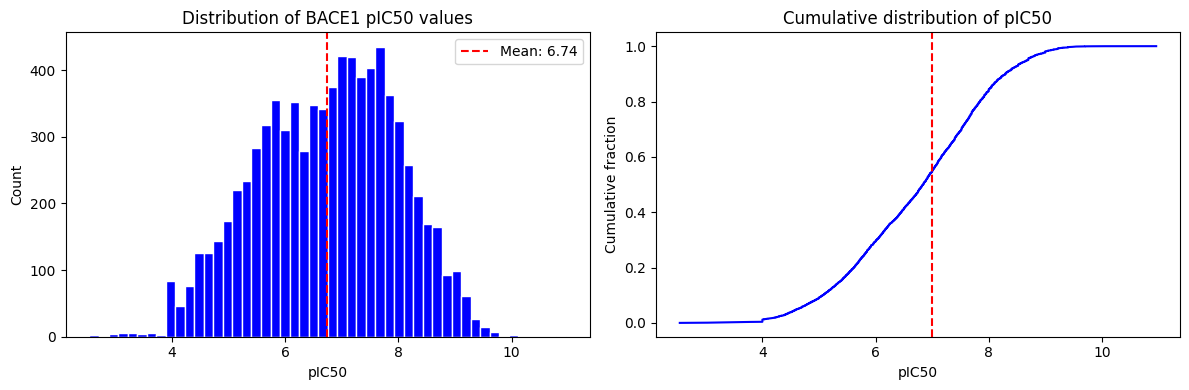

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_dedup['pchembl_value'], bins=50, color='blue', edgecolor='white')
axes[0].set_xlabel('pIC50')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of BACE1 pIC50 values')
axes[0].axvline(df_dedup['pchembl_value'].mean(), color='red',
                linestyle='--', label=f'Mean: {df_dedup['pchembl_value'].mean():.2f}')
axes[0].legend()

sorted_vals = df_dedup['pchembl_value'].sort_values()
axes[1].plot(sorted_vals.values,
             np.linspace(0, 1, len(sorted_vals)),
             color='blue')
axes[1].set_xlabel('pIC50')
axes[1].set_ylabel('Cumulative fraction')
axes[1].set_title('Cumulative distribution of pIC50')
axes[1].axvline(7.0, color='red', linestyle='--', label='pIC50 = 7 (10nM)')

plt.tight_layout()
plt.show


for threshold in [5.0, 6.0, 7.0, 8.0]:
  n = (df_dedup['pchembl_value'] >= threshold).sum()
  pct = n / len(df_dedup) * 100
  print(f'pIC50 >= {threshold} (IC50 <= {10**(- threshold)*1e9:.0f} nM): {n} compounds ({pct:.1f}%)')

## Molecular Featurisation

In [10]:
from rdkit import Chem
from rdkit.Chem import AllChem

def smiles_to_morgan(smiles, radius=2, n_bits=2048):
  mol = Chem.MolFromSmiles(smiles)
  if mol is None:
    return None
  fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
  return np.array(fp)

fingerprints = []
valid_indices = []

for i, smi in enumerate(df_dedup['canonical_smiles']):
  fp = smiles_to_morgan(smi)
  if fp is not None:
    fingerprints.append(fp)
    valid_indices.append(i)

X = np.array(fingerprints)
y = df_dedup['pchembl_value'].iloc[valid_indices].values
smiles_clean = df_dedup['canonical_smiles'].iloc[valid_indices].values

print(f'Failed to parse: {len(df_dedup) - len(valid_indices)} molecues')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

Streaming output truncated to the last 5000 lines.
[23:42:04] DEPRECATION WARNING: please use MorganGenerator
[23:42:04] DEPRECATION WARNING: please use MorganGenerator
[23:42:04] DEPRECATION WARNING: please use MorganGenerator
[23:42:04] DEPRECATION WARNING: please use MorganGenerator
[23:42:04] DEPRECATION WARNING: please use MorganGenerator
[23:42:04] DEPRECATION WARNING: please use MorganGenerator
[23:42:04] DEPRECATION WARNING: please use MorganGenerator
[23:42:04] DEPRECATION WARNING: please use MorganGenerator
[23:42:04] DEPRECATION WARNING: please use MorganGenerator
[23:42:04] DEPRECATION WARNING: please use MorganGenerator
[23:42:04] DEPRECATION WARNING: please use MorganGenerator
[23:42:04] DEPRECATION WARNING: please use MorganGenerator
[23:42:04] DEPRECATION WARNING: please use MorganGenerator
[23:42:04] DEPRECATION WARNING: please use MorganGenerator
[23:42:04] DEPRECATION WARNING: please use MorganGenerator
[23:42:04] DEPRECATION WARNING: please use MorganGenerator
[23:4

Failed to parse: 0 molecues
X shape: (8079, 2048)
y shape: (8079,)


## Scaffold vs Random Split

In [11]:
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict

def get_scaffold(smiles):
  mol = Chem.MolFromSmiles(smiles)
  if mol is None:
    return None
  scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
  return scaffold

scaffolds = defaultdict(list)

for i, smi in enumerate(smiles_clean):
  scaffold = get_scaffold(smi)
  if scaffold is not None:
    scaffolds[scaffold].append(i)

print(f'Unique scaffolds: {len(scaffolds)}')
print(f'Largest scaffold group" {max(len(v) for v in scaffolds.values())} molecules')
print(f'Scaffold groups with only 1 molecule: {sum(1 for v in scaffolds.values() if len(v) == 1)}')

Unique scaffolds: 2852
Largest scaffold group" 166 molecules
Scaffold groups with only 1 molecule: 1796


In [12]:
from sklearn.model_selection import train_test_split

scaffold_groups = sorted(scaffolds.values(), key=lambda x: len(x), reverse=True)

train_idx, test_idx = [], []
test_cutoff = 0.2 * len(smiles_clean)

for group in scaffold_groups:
  if len(test_idx) < test_cutoff:
    test_idx.extend(group)
  else:
    train_idx.extend(group)

X_train_scaffold = X[train_idx]
X_test_scaffold = X[test_idx]
y_train_scaffold = y[train_idx]
y_test_scaffold = y[test_idx]

print('Scaffold Split')
print(f'Train: {len(train_idx)} molecules ({len(train_idx)/len(smiles_clean)*100:.1f}%)')
print(f'Test: {len(test_idx)} molecules ({len(test_idx)/len(smiles_clean)*100:.1f}%)')


X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print('\n Random Split')
print(f'Train: {len(X_train_random)} molecules ({len(X_train_random)/len(smiles_clean)*100:.1f}%)')
print(f'Test: {len(X_test_random)} molecules ({len(X_test_random)/len(smiles_clean)*100:.1f}%)')

train_scaffolds = set(get_scaffold(smiles_clean[i]) for i in train_idx)
test_scaffolds = set(get_scaffold(smiles_clean[i]) for i in test_idx)
overlap = train_scaffolds.intersection(test_scaffolds)
print(f'\nScaffold overlap between train and test: {len(overlap)}')


Scaffold Split
Train: 6452 molecules (79.9%)
Test: 1627 molecules (20.1%)

 Random Split
Train: 6463 molecules (80.0%)
Test: 1616 molecules (20.0%)

Scaffold overlap between train and test: 0


## Training and Hyperparameter Optimisation

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb

cv = KFold(n_splits=5, shuffle=True, random_state=42)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}


rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    n_iter=20,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)


rf_search.fit(X_train_scaffold, y_train_scaffold)
best_rf = rf_search.best_estimator_
print(f'Best RF params: {rf_search.best_params_}')


#LightGBM

lgb_param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, -1],
    'num_leaves': [15, 31, 63],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    lgb_param_grid,
    n_iter=20,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgb_search.fit(X_train_scaffold, y_train_scaffold)
best_lgb = lgb_search.best_estimator_
print(f'Best LGB params: {lgb_search.best_params_}')


def evaluate_model(model, X_train, y_train, X_test, y_test, name, split_type):
  model.fit(X_train, y_train)
  preds = model.predict(X_test)
  rmse = np.sqrt(mean_squared_error(y_test, preds))
  mae = mean_absolute_error(y_test, preds)
  r2 = r2_score(y_test, preds)
  print(f'{name} | {split_type} | RMSE: {rmse:.3f} | MAE: {mae:.3f} | R2: {r2:.3f}')
  return preds, rmse, mae, r2

print(f'Final Evaluation')
rf_preds_scaffold, *rf_scaffold_metrics = evaluate_model(
    best_rf, X_train_scaffold, y_train_scaffold,
    X_test_scaffold, y_test_scaffold, 'Random Forest', 'Scaffold Split'
  )

rf_preds_random, *rf_random_metrics = evaluate_model(
    best_rf, X_train_random, y_train_random,
    X_test_random, y_test_random, 'Random Forest', 'Random Split'
  )

lgb_preds_scaffold, *lgb_scaffold_metrics = evaluate_model(
    best_lgb, X_train_scaffold, y_train_scaffold,
    X_test_scaffold, y_test_scaffold, 'LightGBM', 'Scaffold Split'
  )

lgb_preds_random, *lgb_random_metrics = evaluate_model(
    best_lgb, X_train_random, y_train_random,
    X_test_random, y_test_random, 'LightGBM', 'Random Split'
  )

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best LGB params: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Final Evaluation
Random Forest | Scaffold Split | RMSE: 0.800 | MAE: 0.628 | R2: 0.372
Random Forest | Random Split | RMSE: 0.716 | MAE: 0.538 | R2: 0.647


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM | Scaffold Split | RMSE: 0.771 | MAE: 0.600 | R2: 0.417
LightGBM | Random Split | RMSE: 0.698 | MAE: 0.510 | R2: 0.664


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Results and Analysis

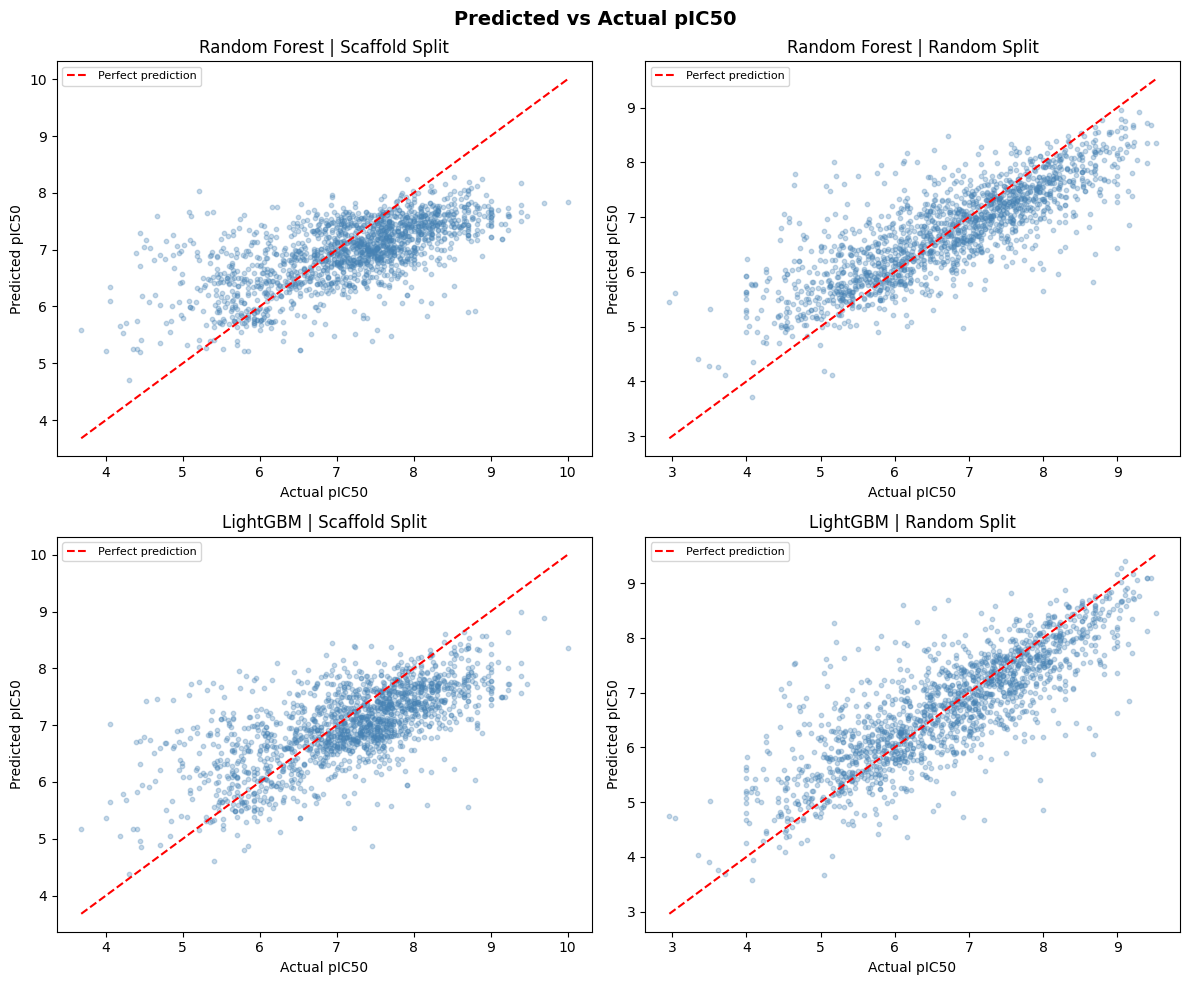

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Predicted vs Actual pIC50', fontsize=14, fontweight='bold')

plot_configs = [
    (rf_preds_scaffold, y_test_scaffold, 'Random Forest | Scaffold Split', axes[0,0]),
    (rf_preds_random, y_test_random, 'Random Forest | Random Split', axes[0,1]),
    (lgb_preds_scaffold, y_test_scaffold, 'LightGBM | Scaffold Split', axes[1,0]),
    (lgb_preds_random, y_test_random, 'LightGBM | Random Split', axes[1,1])
]

for preds, actual, title, ax in plot_configs:
    ax.scatter(actual, preds, alpha=0.3, s=10, color='steelblue')
    min_val = min(actual.min(), preds.min())
    max_val = max(actual.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual pIC50')
    ax.set_ylabel('Predicted pIC50')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

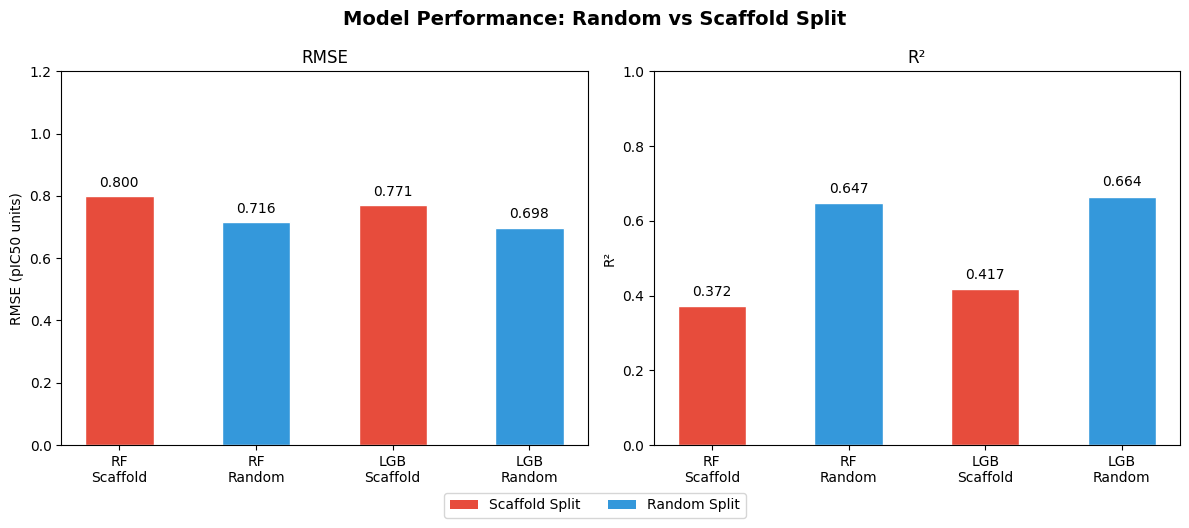

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Performance: Random vs Scaffold Split', fontsize=14, fontweight='bold')

models_names = ['RF\nScaffold', 'RF\nRandom', 'LGB\nScaffold', 'LGB\nRandom']
colors = ['#e74c3c', '#3498db', '#e74c3c', '#3498db']
rmse_vals = [rf_scaffold_metrics[0], rf_random_metrics[0], lgb_scaffold_metrics[0], lgb_random_metrics[0]]
r2_vals = [rf_scaffold_metrics[2], rf_random_metrics[2], lgb_scaffold_metrics[2], lgb_random_metrics[2]]

bars1 = axes[0].bar(models_names, rmse_vals, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('RMSE')
axes[0].set_ylabel('RMSE (pIC50 units)')
axes[0].set_ylim(0, 1.2)
for bar, val in zip(bars1, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

bars2 = axes[1].bar(models_names, r2_vals, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('R²')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1.0)
for bar, val in zip(bars2, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Scaffold Split'),
                   Patch(facecolor='#3498db', label='Random Split')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

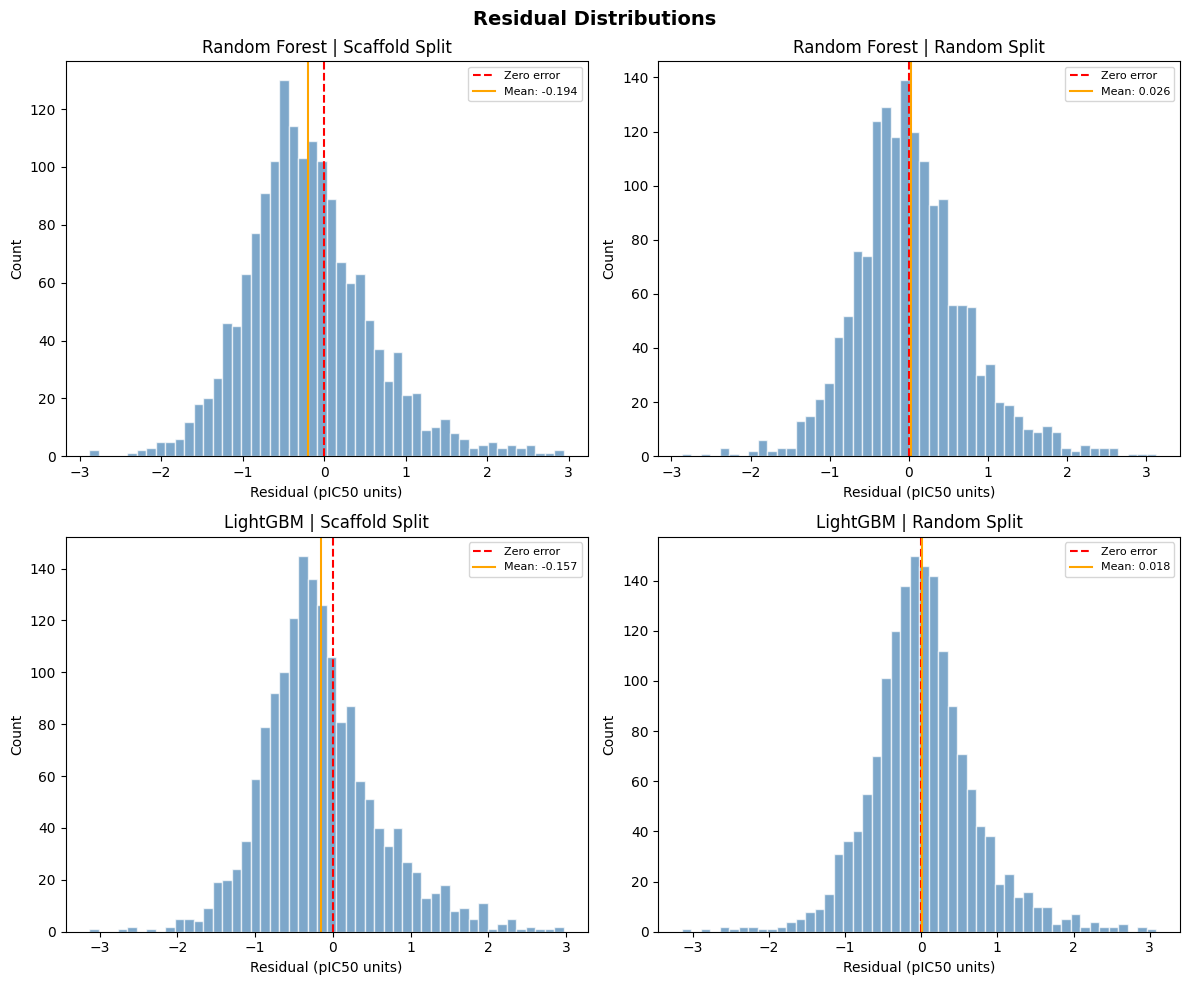

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Residual Distributions', fontsize=14, fontweight='bold')

residual_configs = [
    (rf_preds_scaffold, y_test_scaffold, 'Random Forest | Scaffold Split', axes[0,0]),
    (rf_preds_random, y_test_random, 'Random Forest | Random Split', axes[0,1]),
    (lgb_preds_scaffold, y_test_scaffold, 'LightGBM | Scaffold Split', axes[1,0]),
    (lgb_preds_random, y_test_random, 'LightGBM | Random Split', axes[1,1])
]

for preds, actual, title, ax in residual_configs:
    residuals = preds - actual
    ax.hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
    ax.axvline(x=residuals.mean(), color='orange', linestyle='-',
               linewidth=1.5, label=f'Mean: {residuals.mean():.3f}')
    ax.set_xlabel('Residual (pIC50 units)')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

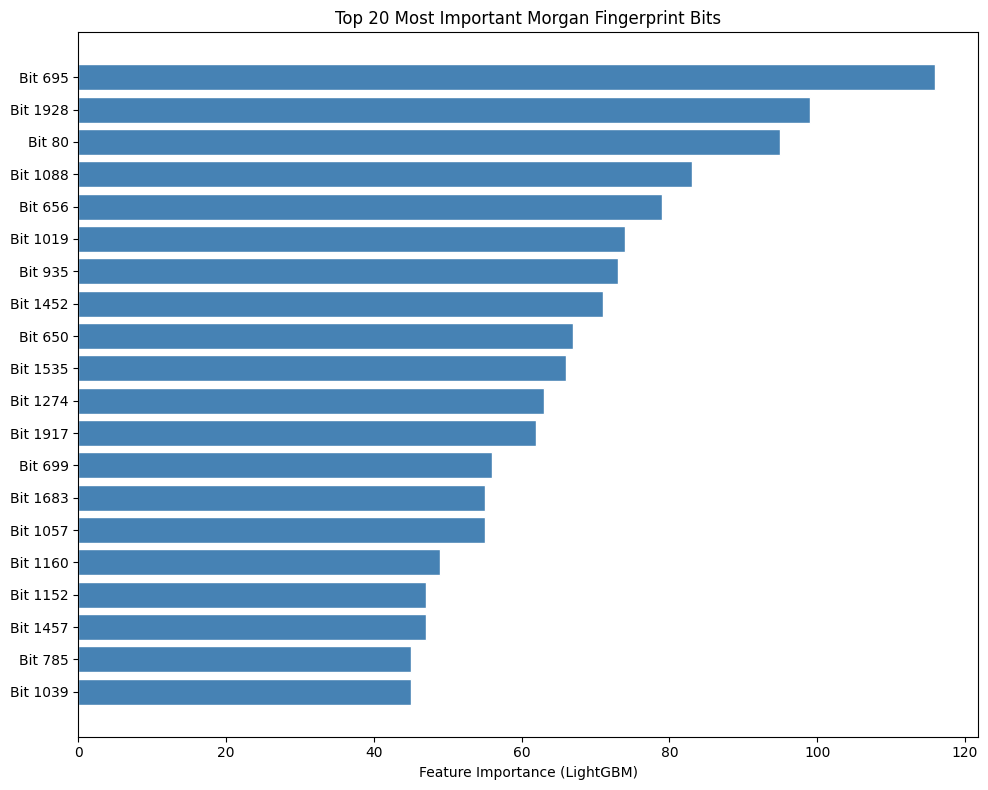


Top 5 most important bits: [ 695 1928   80 1088  656]
Importance scores: [116  99  95  83  79]


In [20]:
fig, ax = plt.subplots(figsize=(10, 8))

importance = best_lgb.feature_importances_
top_n = 20
top_indices = np.argsort(importance)[-top_n:]
top_importance = importance[top_indices]

ax.barh(range(top_n), top_importance, color='steelblue', edgecolor='white')
ax.set_yticks(range(top_n))
ax.set_yticklabels([f'Bit {i}' for i in top_indices])
ax.set_xlabel('Feature Importance (LightGBM)')
ax.set_title('Top 20 Most Important Morgan Fingerprint Bits')

plt.tight_layout()
plt.show()

print(f"\nTop 5 most important bits: {top_indices[-5:][::-1]}")
print(f"Importance scores: {top_importance[-5:][::-1].round(3)}")

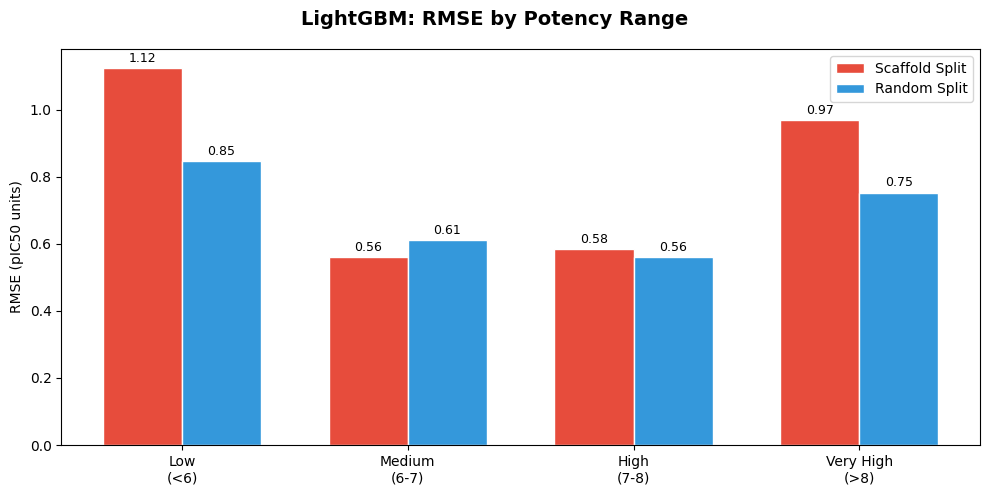


Scaffold split test set composition:
  pIC50 0-6: 246 molecules
  pIC50 6-7: 370 molecules
  pIC50 7-8: 686 molecules
  pIC50 8-12: 325 molecules


In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('LightGBM: RMSE by Potency Range', fontsize=14, fontweight='bold')

bins = [(0, 6, 'Low\n(<6)'), (6, 7, 'Medium\n(6-7)'), (7, 8, 'High\n(7-8)'), (8, 12, 'Very High\n(>8)')]

def rmse_by_bin(preds, actual, bins):
    rmses, counts = [], []
    for low, high, _ in bins:
        mask = (actual >= low) & (actual < high)
        if mask.sum() > 0:
            rmse = np.sqrt(mean_squared_error(actual[mask], preds[mask]))
            rmses.append(rmse)
            counts.append(mask.sum())
        else:
            rmses.append(0)
            counts.append(0)
    return rmses, counts

bin_labels = [b[2] for b in bins]
rmse_scaffold, _ = rmse_by_bin(lgb_preds_scaffold, y_test_scaffold, bins)
rmse_random, _ = rmse_by_bin(lgb_preds_random, y_test_random, bins)

x = np.arange(len(bin_labels))
width = 0.35

bars1 = ax.bar(x - width/2, rmse_scaffold, width, label='Scaffold Split', color='#e74c3c', edgecolor='white')
bars2 = ax.bar(x + width/2, rmse_random, width, label='Random Split', color='#3498db', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(bin_labels)
ax.set_ylabel('RMSE (pIC50 units)')
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nScaffold split test set composition:")
_, counts = rmse_by_bin(lgb_preds_scaffold, y_test_scaffold, bins)
for (low, high, label), count in zip(bins, counts):
    print(f"  pIC50 {low}-{high}: {count} molecules")